In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType
import qcodes as qc
from qcodes import Station, Parameter
from qcodes.dataset import (
    initialise_database,
    load_or_create_experiment,
    Measurement,
)
import csv
import os
from datetime import datetime

In [2]:
# ─────────────────────────────────────────────
# 1. QCoDeS STATION SETUP
# ─────────────────────────────────────────────
station = Station()

In [ ]:
# ─────────────────────────────────────────────
# 2. ACQUISITION PARAMETERS
# ─────────────────────────────────────────────
DEVICE       = "Dev1"              # check your name in NI MAX
CHANNEL      = f"{DEVICE}/ai14"   # circuit signal

SAMPLE_RATE  = 25_000             # Hz
NUM_SAMPLES  = 50_000           # total samples to acquire
CHUNK_SAMPLES = 500_000              # samples per read (10 ms chunks)
V_MIN, V_MAX = -1.5, 1.5           # expected voltage range at DAQ input

In [4]:
# ─────────────────────────────────────────────
# 3. DATABASE & EXPERIMENT
# ─────────────────────────────────────────────
initialise_database()   # creates qcodes_experiments.db if not present
exp = load_or_create_experiment(
    experiment_name="signal_acquisition",
    sample_name="test",
)

In [13]:
# ─────────────────────────────────────────────
# 4. RUN A MEASUREMENT
#    Writes every chunk to both the QCoDeS database
#    and a CSV file as it is acquired. If the DAQ
#    is disconnected mid-run, all data collected
#    up to that point is already saved.
# ─────────────────────────────────────────────

# Prepare output CSV path (run_id not known yet, added after)
timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = "acquisitions"
os.makedirs(output_dir, exist_ok=True)
csv_path   = os.path.join(output_dir, f"run_{timestamp}.csv")

meas = Measurement(exp)
meas.register_custom_parameter("time",    label="Time",    unit="s")
meas.register_custom_parameter("voltage", label="Voltage", unit="V",
                                setpoints=["time"])

with meas.run() as datasaver, open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time_s", "voltage_V"])   # header

    with nidaqmx.Task() as task:
        task.ai_channels.add_ai_voltage_chan(
            CHANNEL,
            terminal_config=TerminalConfiguration.RSE,
            min_val=V_MIN, max_val=V_MAX,
        )
        task.timing.cfg_samp_clk_timing(
            rate=SAMPLE_RATE,
            sample_mode=AcquisitionType.CONTINUOUS,
        )
        task.timing.cfg_samp_clk_timing(
        rate=SAMPLE_RATE,
        sample_mode=AcquisitionType.CONTINUOUS,
        )
        task.in_stream.input_buf_size = 500_000
        task.start()
        samples_collected = 0

        try:
            while samples_collected < NUM_SAMPLES:
                chunk = np.array(task.read(
                    number_of_samples_per_channel=CHUNK_SAMPLES,
                    timeout=10.0,
                ))
                t_chunk = (samples_collected + np.arange(len(chunk))) / SAMPLE_RATE

                # Write chunk to QCoDeS database immediately
                datasaver.add_result(
                    ("time",    t_chunk),
                    ("voltage", chunk),
                )

                # Write chunk to CSV immediately and flush to disk
                writer.writerows(zip(t_chunk, chunk))
                f.flush()

                samples_collected += len(chunk)

        except Exception as e:
            print(f"Acquisition interrupted after {samples_collected} samples "
                  f"({samples_collected/SAMPLE_RATE:.2f} s): {e}")
            print("Data saved up to interruption point — nothing lost.")

    run_id = datasaver.run_id

# Rename CSV to include run_id now that we have it
final_csv_path = os.path.join(output_dir, f"run_{run_id}_{timestamp}.csv")
os.rename(csv_path, final_csv_path)

print(f"QCoDeS run ID: {run_id}")
print(f"Data written to: {final_csv_path}")

Starting experimental run with id: 126. 
Acquisition interrupted after 500000 samples (1.00 s): The application is not able to keep up with the hardware acquisition.
Increasing the buffer size, reading the data more frequently, or specifying a fixed number of samples to read instead of reading all available samples might correct the problem.
Property: DAQmx_Read_RelativeTo
Corresponding Value: DAQmx_Val_CurrReadPos
Property: DAQmx_Read_Offset
Corresponding Value: 0

Task Name: _unnamedTask<4>

Status Code: -200279
Data saved up to interruption point — nothing lost.
QCoDeS run ID: 126
Data written to: acquisitions\run_126_20260601_111946.csv


In [27]:
# ─────────────────────────────────────────────
# 4. RUN A MEASUREMENT (threaded)
#    A fast reader thread pulls data from the DAQ
#    into a queue. The main thread drains the queue
#    and writes to database + CSV.
# ─────────────────────────────────────────────
import queue
import threading

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = "acquisitions"
os.makedirs(output_dir, exist_ok=True)
csv_path   = os.path.join(output_dir, f"run_{timestamp}.csv")

data_queue   = queue.Queue()
stop_event   = threading.Event()
reader_error = [None]   # box to pass exceptions from the reader thread

def daq_reader():
    """Reads from DAQ as fast as possible and pushes chunks into the queue."""
    try:
        with nidaqmx.Task() as task:
            task.ai_channels.add_ai_voltage_chan(
                CHANNEL,
                terminal_config=TerminalConfiguration.RSE,
                min_val=V_MIN, max_val=V_MAX,
            )
            task.timing.cfg_samp_clk_timing(
                rate=SAMPLE_RATE,
                sample_mode=AcquisitionType.CONTINUOUS,
            )
            task.in_stream.input_buf_size = 500_000   # 1 second of buffer
            task.start()

            samples_collected = 0
            while samples_collected < NUM_SAMPLES and not stop_event.is_set():
                chunk = np.array(task.read(
                    number_of_samples_per_channel=CHUNK_SAMPLES,
                    timeout=10.0,
                ))
                data_queue.put((samples_collected, chunk))
                samples_collected += len(chunk)

    except Exception as e:
        reader_error[0] = e
    finally:
        data_queue.put(None)   # sentinel: signals writer that we're done

# Start the reader thread
reader_thread = threading.Thread(target=daq_reader, daemon=True)
reader_thread.start()

# Main thread: drain queue and write to database + CSV
meas = Measurement(exp)
meas.register_custom_parameter("time",    label="Time",    unit="s")
meas.register_custom_parameter("voltage", label="Voltage", unit="V",
                                setpoints=["time"])

samples_written = 0

with meas.run() as datasaver, open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time_s", "voltage_V"])

    while True:
        item = data_queue.get()
        if item is None:   # sentinel received — reader is done
            break

        sample_offset, chunk = item
        t_chunk = (sample_offset + np.arange(len(chunk))) / SAMPLE_RATE

        datasaver.add_result(
            ("time",    t_chunk),
            ("voltage", chunk),
        )
        writer.writerows(zip(t_chunk, chunk))
        f.flush()

        samples_written += len(chunk)

    if reader_error[0] is not None:
        print(f"Acquisition interrupted after {samples_written} samples "
              f"({samples_written/SAMPLE_RATE:.2f} s): {reader_error[0]}")
        print("Data saved up to interruption point — nothing lost.")

reader_thread.join()
run_id = datasaver.run_id

final_csv_path = os.path.join(output_dir, f"run_{run_id}_{timestamp}.csv")
os.rename(csv_path, final_csv_path)

print(f"QCoDeS run ID: {run_id}")
print(f"Data written to: {final_csv_path}")

Starting experimental run with id: 135. 
QCoDeS run ID: 135
Data written to: acquisitions\run_135_20260601_113239.csv


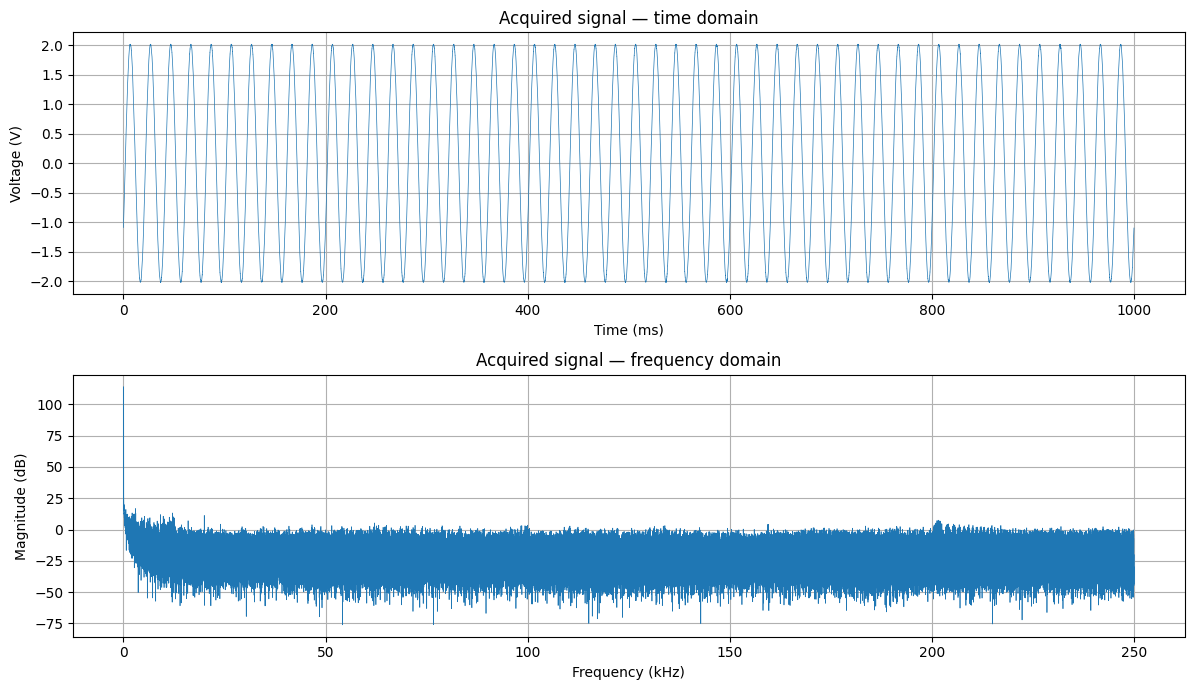

In [28]:
# ─────────────────────────────────────────────
# 5. PLOT
#    Loads the full acquisition from the QCoDeS
#    database using the run_id saved above.
# ─────────────────────────────────────────────
from qcodes.dataset import load_by_id

dataset = load_by_id(run_id)
data    = dataset.get_parameter_data()

time    = data["voltage"]["time"]
signal  = data["voltage"]["voltage"]
time_ms = time * 1e3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# Time domain
ax1.plot(time_ms, signal, linewidth=0.5)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Voltage (V)")
ax1.set_title("Acquired signal — time domain")
ax1.grid(True)

# Frequency domain
N  = len(signal)
yf = np.abs(np.fft.fft(signal))[:N//2]
xf = np.fft.fftfreq(N, 1 / SAMPLE_RATE)[:N//2]
ax2.plot(xf / 1e3, 20 * np.log10(yf + 1e-12), linewidth=0.5)
ax2.set_xlabel("Frequency (kHz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_title("Acquired signal — frequency domain")
ax2.grid(True)

plt.tight_layout()
plt.show()